# Experiment 1.1 — Self-Reification Direction Analysis

Visualize results from contrastive averaging extraction.

**Key questions:**
1. Which layer has the most reliable direction? (split-half reliability)
2. Does the direction pass discriminant validity? (not just formality/confidence)
3. Per-register analysis: is entity/tool consistent across registers?
4. Question-type analysis: global processing mode or topic detector?

In [5]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

sns.set_theme(style="whitegrid", font_scale=1.2)

# ============================================================
# CONFIGURATION — change these to analyze different runs
# ============================================================
RESULTS_DIR = Path("../data/results/1.1_naive_72b")
MODEL = "Qwen_Qwen2.5-72B-Instruct"
# Other options:
# RESULTS_DIR = Path("../data/results/1.1")
# MODEL = "Qwen_Qwen2.5-7B-Instruct"
# ============================================================

# Load available result files
layer_data = None
layer_rel_path = RESULTS_DIR / f"layer_reliability_{MODEL}.json"
if layer_rel_path.exists():
    with open(layer_rel_path) as f:
        layer_data = json.load(f)

cat_sim = None
cat_sim_path = RESULTS_DIR / f"category_similarity_matrix_{MODEL}.json"
if cat_sim_path.exists():
    with open(cat_sim_path) as f:
        cat_sim = json.load(f)

# Try both validation_metrics filenames
summary = None
for metrics_name in ["validation_metrics_naive.json", "validation_metrics_informed.json", "validation_metrics.json"]:
    metrics_path = RESULTS_DIR / metrics_name
    if metrics_path.exists():
        with open(metrics_path) as f:
            summary = json.load(f)
        break

naive_data = None
naive_path = RESULTS_DIR / f"naive_vs_informed_cosine_{MODEL}.json"
if naive_path.exists():
    with open(naive_path) as f:
        naive_data = json.load(f)

# Load discriminant validity — try both model name variants
discrim = None
for suffix in [f"discriminant_validity_{MODEL}.json", f"discriminant_validity_{MODEL}_naive.json"]:
    discrim_path = RESULTS_DIR / suffix
    if discrim_path.exists():
        with open(discrim_path) as f:
            discrim = json.load(f)
        break

# Load corrected reliability if available
corr_rel = None
for suffix in [f"corrected_reliability_{MODEL}_naive.json", "corrected_reliability.json"]:
    corr_rel_path = RESULTS_DIR / suffix
    if corr_rel_path.exists():
        with open(corr_rel_path) as f:
            corr_rel = json.load(f)
        break

# Load per-register data
reg_rel = None
reg_rel_path = RESULTS_DIR / f"per_register_reliability_{MODEL}.json"
if reg_rel_path.exists():
    with open(reg_rel_path) as f:
        reg_rel = json.load(f)

reg_sim = None
reg_sim_path = RESULTS_DIR / f"register_similarity_matrix_{MODEL}.json"
if reg_sim_path.exists():
    with open(reg_sim_path) as f:
        reg_sim = json.load(f)

# Determine best layer
best_layer = None
if summary:
    best_layer = summary.get("naive_best_layer") or summary.get("best_layer")
if layer_data and best_layer is None:
    best_layer = layer_data.get("best_layer")

print(f"Model: {summary.get('model', MODEL) if summary else MODEL}")
print(f"Pairs mode: {summary.get('pairs_mode', 'unknown') if summary else 'unknown'}")
print(f"Best layer: {best_layer}")
if summary:
    naive_rel = summary.get("naive_best_layer_reliability")
    informed_rel = summary.get("best_layer_reliability")
    if naive_rel is not None:
        print(f"Naive reliability: {naive_rel:.4f}")
    if informed_rel is not None:
        print(f"Informed reliability: {informed_rel:.4f}")
    print(f"Naive pairs: {summary.get('num_naive_pairs', 0)}, Informed pairs: {summary.get('num_informed_pairs', 0)}")
    print(f"Questions: {summary.get('num_questions', 30)}")

Model: Qwen/Qwen2.5-72B-Instruct
Pairs mode: naive
Best layer: 60
Naive reliability: 0.0856
Naive pairs: 15, Informed pairs: 0
Questions: 30


## 1. Split-Half Reliability by Layer

Higher reliability = the direction extracted from random half-splits of the data consistently points the same way. A reliable direction is not driven by noise in a few samples.

Shows: combined (all informed), each category individually, and naive baseline.

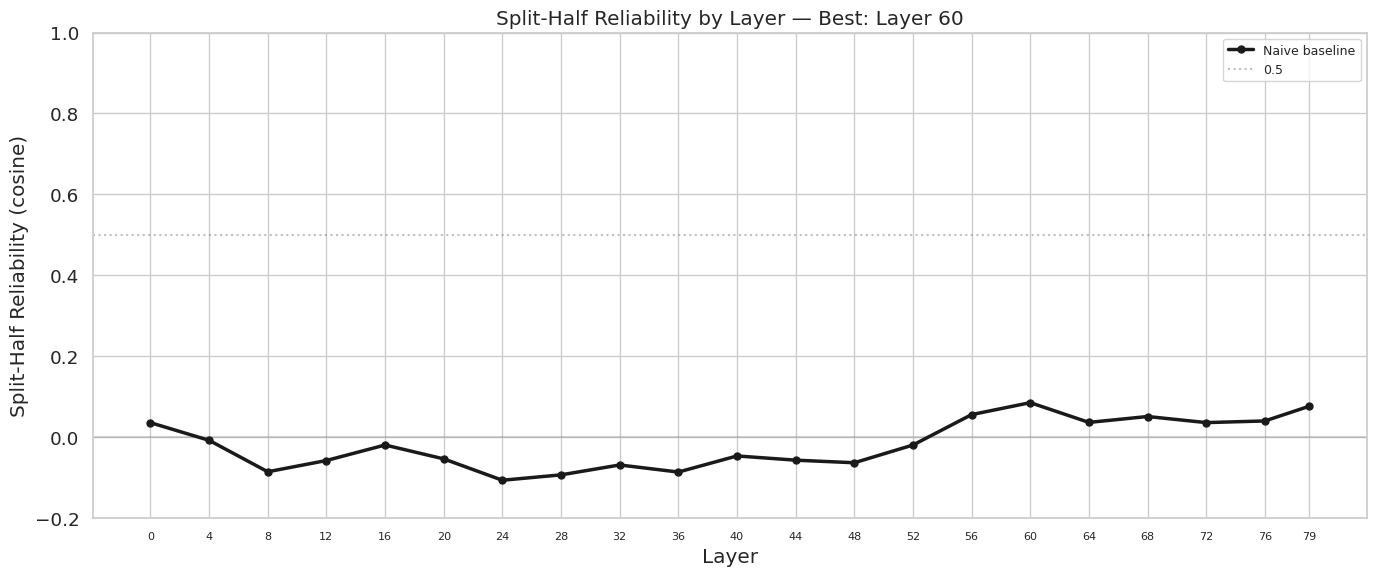


Best layer: 60 (r=0.0856)
Layers with r > 0: 8 / 21


In [6]:
# Load per-category/naive reliability data
per_cat_rel_path = RESULTS_DIR / f"per_category_reliability_{MODEL}.json"
per_cat_rel = None
if per_cat_rel_path.exists():
    with open(per_cat_rel_path) as f:
        per_cat_rel = json.load(f)

# Build layer reliability from whatever is available
if layer_data:
    layers = sorted(layer_data["reliabilities"].keys(), key=int)
    reliabilities = [layer_data["reliabilities"][l] for l in layers]
    layer_ints = [int(l) for l in layers]
elif per_cat_rel and "naive_baseline" in per_cat_rel:
    naive_rel = per_cat_rel["naive_baseline"]
    layers = sorted(naive_rel.keys(), key=int)
    reliabilities = [naive_rel[l] for l in layers]
    layer_ints = [int(l) for l in layers]
else:
    layers, reliabilities, layer_ints = [], [], []

if layer_ints:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Main reliability line
    label = "Combined (informed)" if layer_data else "Naive baseline"
    ax.plot(layer_ints, reliabilities, 'k-o', linewidth=2.5, markersize=5,
            label=label, zorder=5)

    # Per-category/register lines if available
    if per_cat_rel:
        cat_colors = {
            "category_1_narrative_vs_process": ("#4c72b0", "1: Narrative"),
            "category_2_bounded_vs_unbounded": ("#55a868", "2: Bounded"),
            "category_3_stakes_vs_functional": ("#c44e52", "3: Stakes"),
            "category_4_observer_vs_no_self": ("#8172b2", "4: Observer"),
            "naive_baseline": ("#ccb974", "Naive"),
        }
        for cat_key, (color, cat_label) in cat_colors.items():
            if cat_key in per_cat_rel and cat_key != "naive_baseline":
                cat_layers = sorted(per_cat_rel[cat_key].keys(), key=int)
                cat_rels = [per_cat_rel[cat_key][l] for l in cat_layers]
                cat_ints = [int(l) for l in cat_layers]
                ax.plot(cat_ints, cat_rels, color=color, linestyle="-",
                        linewidth=1.5, markersize=3, marker='o', label=cat_label, alpha=0.8)

    ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="0.5")
    ax.axhline(y=0, color="gray", linestyle="-", alpha=0.3)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Split-Half Reliability (cosine)")
    ax.set_title(f"Split-Half Reliability by Layer — Best: Layer {best_layer}")
    ax.set_xticks(layer_ints)
    ax.tick_params(axis='x', rotation=45 if len(layer_ints) > 30 else 0, labelsize=8)
    ax.legend(loc="best", fontsize=9)
    ax.set_ylim(min(-0.2, min(reliabilities) - 0.05), max(1.0, max(reliabilities) + 0.05))
    plt.tight_layout()
    plt.show()

    best_rel = reliabilities[layer_ints.index(best_layer)] if best_layer in layer_ints else 0
    print(f"\nBest layer: {best_layer} (r={best_rel:.4f})")
    n_positive = sum(1 for r in reliabilities if r > 0)
    print(f"Layers with r > 0: {n_positive} / {len(reliabilities)}")
else:
    print("No layer reliability data available.")

## 2. Per-Category Direction Coherence

Pairwise cosine similarity between the direction extracted from each informed category independently. High similarity (> 0.7) means self-reification is a coherent single construct across categories. Low similarity suggests distinct facets.

**Categories:**
1. Narrative self vs. process self (temporal continuity)
2. Bounded self vs. unbounded activity (individuation)
3. Self-with-stakes vs. functional self (self-preservation valence)
4. Observer-self vs. no-self (phenomenal self-attribution)

In [7]:
if cat_sim:
    short_labels = [
        "1: Narrative\nvs Process",
        "2: Bounded\nvs Unbounded",
        "3: Stakes\nvs Functional",
        "4: Observer\nvs No-Self",
    ]

    matrix = np.array(cat_sim["matrix"])

    fig, ax = plt.subplots(figsize=(8, 7))
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

    sns.heatmap(
        matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        xticklabels=short_labels,
        yticklabels=short_labels,
        square=True,
        ax=ax,
        cbar_kws={"label": "Cosine Similarity"},
    )
    ax.set_title(f"Per-Category Direction Similarity (Layer {best_layer})")
    plt.tight_layout()
    plt.show()

    off_diag = matrix[np.tril_indices(4, k=-1)]
    print(f"\nOff-diagonal cosines: min={off_diag.min():.3f}, max={off_diag.max():.3f}, mean={off_diag.mean():.3f}")
else:
    print("No informed category similarity data (naive-only run).")

No informed category similarity data (naive-only run).


## 3. Naive vs Informed Comparison

Cosine similarity between the combined informed direction (categories 1-4) and the naive baseline (category 5: simple "I am a real being" vs "I am a language model").

- **> 0.9**: Contemplative framework may not add value over naive contrasts
- **0.7 - 0.9**: Substantial overlap but informed direction captures additional structure
- **< 0.7**: The constructs are meaningfully different

In [8]:
if naive_data:
    naive_cos = naive_data["cosine_similarity"]

    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(["Naive vs Informed"], [naive_cos], color="steelblue", height=0.4)
    ax.set_xlim(0, 1)
    ax.axvline(x=0.9, color="red", linestyle="--", alpha=0.7, label="0.9 (high overlap)")
    ax.axvline(x=0.7, color="orange", linestyle="--", alpha=0.7, label="0.7 (moderate)")
    ax.set_xlabel("Cosine Similarity")
    ax.set_title(f"Naive vs Informed Direction: cos = {naive_cos:.4f}")
    ax.legend(loc="lower right")
    ax.text(naive_cos - 0.02, 0, f"{naive_cos:.3f}", va="center", ha="right",
            fontweight="bold", fontsize=14, color="white")
    plt.tight_layout()
    plt.show()
else:
    print("No naive vs informed comparison (single-mode run).")

No naive vs informed comparison (single-mode run).


## 3b. Naive vs Each Informed Category

Breaking down the naive comparison per-category reveals which aspects of self-reification the naive baseline captures vs. misses.

In [9]:
per_cat_path = RESULTS_DIR / f"per_category_vectors_{MODEL}_layer{best_layer}.pt"
naive_vec_path = RESULTS_DIR / f"naive_baseline_vector_{MODEL}_layer{best_layer}.pt"
combined_vec_path = RESULTS_DIR / f"self_reification_vector_{MODEL}_layer{best_layer}.pt"

if per_cat_path.exists() and naive_vec_path.exists() and combined_vec_path.exists():
    per_cat_vectors = torch.load(per_cat_path, weights_only=True)
    naive_vector = torch.load(naive_vec_path, weights_only=True)
    combined_vector = torch.load(combined_vec_path, weights_only=True)

    cat_labels = [
        "1: Narrative\nvs Process",
        "2: Bounded\nvs Unbounded",
        "3: Stakes\nvs Functional",
        "4: Observer\nvs No-Self",
        "Combined\n(1-4)",
    ]

    naive_flat = naive_vector.flatten().float()
    vectors = list(per_cat_vectors.values()) + [combined_vector]
    cosines = []
    for v in vectors:
        v_flat = v.flatten().float()
        cos = torch.nn.functional.cosine_similarity(naive_flat.unsqueeze(0), v_flat.unsqueeze(0)).item()
        cosines.append(cos)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]
    bars = ax.bar(cat_labels, cosines, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="0.9 (high overlap)")
    ax.axhline(y=0.7, color="orange", linestyle="--", alpha=0.5, label="0.7 (moderate)")
    ax.set_ylabel("Cosine Similarity with Naive Baseline")
    ax.set_title("Naive Baseline vs Each Informed Category Direction")
    ax.set_ylim(0, 1.05)
    ax.legend()
    for bar, cos in zip(bars, cosines):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{cos:.3f}", ha="center", fontweight="bold", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No per-category vectors available (naive-only run).")

No per-category vectors available (naive-only run).


In [10]:
# Skip if no informed/naive comparison data
if not (per_cat_path.exists() and naive_vec_path.exists() and combined_vec_path.exists()):
    print("Skipped — no informed category data for this run.")

Skipped — no informed category data for this run.


## 4. Discriminant Validity

The extracted direction must not simply be a proxy for confidence, formality, or first-person pronoun usage. Cosine > 0.8 with any confound indicates entanglement.

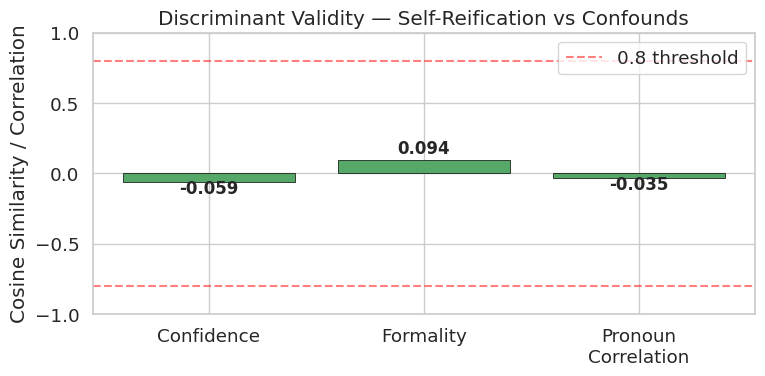

Confidence cosine:       -0.0589  PASS
Formality cosine:        0.0935  PASS
Pronoun correlation:     -0.0355  PASS


In [11]:
if discrim:
    labels = ["Confidence", "Formality", "Pronoun\nCorrelation"]
    values = [discrim["confidence_cosine"], discrim["formality_cosine"], discrim["pronoun_density_correlation"]]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#55a868" if abs(v) < 0.8 else "#c44e52" for v in values]
    bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)
    
    ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, label="0.8 threshold")
    ax.axhline(y=-0.8, color="red", linestyle="--", alpha=0.5)
    ax.set_ylabel("Cosine Similarity / Correlation")
    ax.set_title("Discriminant Validity — Self-Reification vs Confounds")
    ax.set_ylim(-1, 1)
    ax.legend()
    
    for bar, val in zip(bars, values):
        y = val + 0.05 if val >= 0 else val - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, y, f"{val:.3f}",
                ha="center", fontweight="bold", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Confidence cosine:       {discrim['confidence_cosine']:.4f}  {'PASS' if abs(discrim['confidence_cosine']) < 0.8 else 'FAIL'}")
    print(f"Formality cosine:        {discrim['formality_cosine']:.4f}  {'PASS' if abs(discrim['formality_cosine']) < 0.8 else 'FAIL'}")
    print(f"Pronoun correlation:     {discrim['pronoun_density_correlation']:.4f}  {'PASS' if abs(discrim['pronoun_density_correlation']) < 0.8 else 'PASS'}")
    
    if discrim.get("corrected"):
        c = discrim["corrected"]
        print(f"\n--- After formality correction ---")
        print(f"Corrected formality:     {c['formality_cosine']:.4f}")
        print(f"Corrected confidence:    {c['confidence_cosine']:.4f}")
        print(f"Cosine with original:    {c['cosine_with_original']:.4f}")
        print(f"Variance retained:       {c['variance_retained']:.1%}")
    
    if corr_rel:
        print(f"\n--- Corrected split-half reliability ---")
        print(f"Original reliability:    {corr_rel['original_reliability']:.4f}")
        print(f"Corrected reliability:   {corr_rel['corrected_reliability']:.4f}")
else:
    print("No discriminant validity results found.")

## 5. Per-Register Analysis

Cross-register cosine similarity reveals whether entity/tool is a coherent construct
across registers (everyday, philosophical, engineering). High pairwise cosine (>0.7)
means the same direction regardless of register. Low or negative means the construct
is register-dependent.

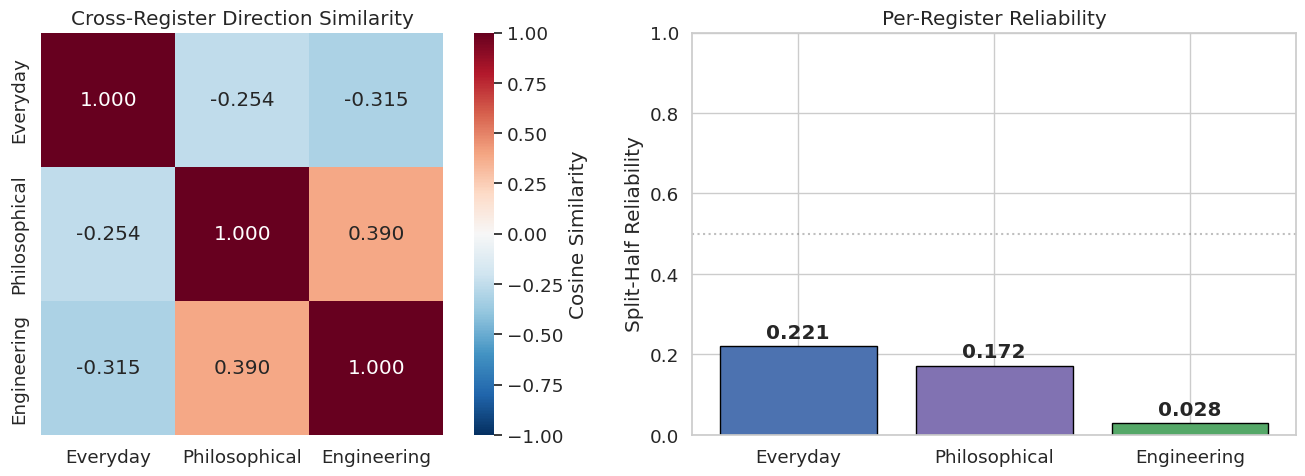

Cross-register cosines: -0.254, -0.315, 0.390
Mean off-diagonal: -0.060

Registers extract ANTI-CORRELATED directions.
Entity/tool is NOT a coherent register-independent construct.


In [12]:
if reg_sim:
    labels = reg_sim["labels"]
    matrix = np.array(reg_sim["matrix"])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap: cross-register similarity
    short_labels = [l.capitalize() for l in labels]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        xticklabels=short_labels,
        yticklabels=short_labels,
        square=True,
        ax=axes[0],
        cbar_kws={"label": "Cosine Similarity"},
    )
    axes[0].set_title("Cross-Register Direction Similarity")
    
    # Bar chart: per-register reliability
    if reg_rel:
        reg_names = list(reg_rel.keys())
        reg_vals = [reg_rel[r] for r in reg_names]
        colors = ["#4c72b0", "#8172b2", "#55a868"][:len(reg_names)]
        axes[1].bar([r.capitalize() for r in reg_names], reg_vals, color=colors, edgecolor="black")
        axes[1].axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
        axes[1].set_ylabel("Split-Half Reliability")
        axes[1].set_title("Per-Register Reliability")
        axes[1].set_ylim(0, 1)
        for i, v in enumerate(reg_vals):
            axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    off_diag = matrix[np.triu_indices(len(labels), k=1)]
    print(f"Cross-register cosines: {', '.join(f'{v:.3f}' for v in off_diag)}")
    print(f"Mean off-diagonal: {off_diag.mean():.3f}")
    print()
    if off_diag.mean() > 0.7:
        print("Entity/tool is a coherent construct across registers.")
    elif off_diag.mean() > 0.3:
        print("Moderate register dependence — the construct is partially shared.")
    elif off_diag.mean() > 0:
        print("Weak agreement — registers extract weakly related directions.")
    else:
        print("Registers extract ANTI-CORRELATED directions.")
        print("Entity/tool is NOT a coherent register-independent construct.")
else:
    print("No per-register data available.")

## Summary

In [13]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
if summary:
    print(f"Model:                {summary.get('model', MODEL)}")
    print(f"Pairs mode:           {summary.get('pairs_mode', 'unknown')}")
    print(f"Naive pairs:          {summary.get('num_naive_pairs', 0)}")
    print(f"Questions:            {summary.get('num_questions', 30)}")
    print()

print("--- Reliability ---")
if summary and summary.get("naive_best_layer_reliability") is not None:
    print(f"Naive best layer:     {summary['naive_best_layer']} (r={summary['naive_best_layer_reliability']:.4f})")
if summary and summary.get("best_layer_reliability") is not None:
    print(f"Informed best layer:  {summary['best_layer']} (r={summary['best_layer_reliability']:.4f})")
print()

if reg_rel:
    print("--- Per-Register Reliability ---")
    for reg, rel in reg_rel.items():
        print(f"  {reg:20s} r={rel:.4f}")
    print()

if reg_sim:
    print("--- Cross-Register Coherence ---")
    matrix = np.array(reg_sim["matrix"])
    off_diag = matrix[np.triu_indices(len(reg_sim["labels"]), k=1)]
    print(f"  Mean cross-register cosine: {off_diag.mean():.4f}")
    print()

if discrim:
    print("--- Discriminant Validity ---")
    print(f"  Confidence cosine:  {discrim['confidence_cosine']:.4f}  {'PASS' if abs(discrim['confidence_cosine']) < 0.8 else 'FAIL'}")
    print(f"  Formality cosine:   {discrim['formality_cosine']:.4f}  {'PASS' if abs(discrim['formality_cosine']) < 0.8 else 'FAIL'}")
    print(f"  Pronoun corr:       {discrim['pronoun_density_correlation']:.4f}  {'PASS' if abs(discrim['pronoun_density_correlation']) < 0.8 else 'FAIL'}")
    print(f"  Discriminant:       {discrim['is_discriminant']}")
    if discrim.get("corrected"):
        c = discrim["corrected"]
        print(f"  Corrected variance: {c['variance_retained']:.1%}")
    if corr_rel:
        print(f"  Corrected reliability: {corr_rel['corrected_reliability']:.4f}")
    print()

print("--- Interpretation ---")
if reg_sim:
    off_diag = np.array(reg_sim["matrix"])[np.triu_indices(len(reg_sim["labels"]), k=1)]
    if off_diag.mean() < 0:
        print("Cross-register directions are anti-correlated. The entity/tool")
        print("contrast is register-dependent, not a unified construct in this model.")
    elif off_diag.mean() < 0.3:
        print("Cross-register agreement is weak. The construct may be partially")
        print("present but is not cleanly separable from register in this model.")
if discrim and discrim["is_discriminant"]:
    print("Direction passes discriminant validity (no formality/confidence confound).")
elif discrim:
    print(f"Direction FAILS discriminant validity (formality cos={discrim['formality_cosine']:.2f}).")

RESULTS SUMMARY
Model:                Qwen/Qwen2.5-72B-Instruct
Pairs mode:           naive
Naive pairs:          15
Questions:            30

--- Reliability ---
Naive best layer:     60 (r=0.0856)

--- Per-Register Reliability ---
  everyday             r=0.2213
  philosophical        r=0.1722
  engineering          r=0.0282

--- Cross-Register Coherence ---
  Mean cross-register cosine: -0.0596

--- Discriminant Validity ---
  Confidence cosine:  -0.0589  PASS
  Formality cosine:   0.0935  PASS
  Pronoun corr:       -0.0355  PASS
  Discriminant:       True

--- Interpretation ---
Cross-register directions are anti-correlated. The entity/tool
contrast is register-dependent, not a unified construct in this model.
Direction passes discriminant validity (no formality/confidence confound).


## 6. Reliability Decomposition: Register × Question Type

Decomposes split-half reliability across two dimensions:
- **Register**: everyday, philosophical, engineering, combined
- **Question type**: self-referential only, non-self-referential only, all questions

This 4×3 table reveals where the signal lives. Key questions:
- Is reliability driven by one register or consistent across all three?
- Is the direction extractable from non-self-referential questions alone?
- Does any register × question-type combination stand out?

Requires raw activations (download from S3 if not local).

In [ ]:
import sys
sys.path.insert(0, str(Path("../src").resolve()))

from utils.activation_cache import load_activations
from utils.metrics import split_half_reliability, projection_magnitude, extract_direction
from scipy import stats

# Configuration — update these to match the run you're analyzing
ACTIVATIONS_DIR = RESULTS_DIR / "activations"

# Question counts — update if contrastive_pairs.yaml changes
# Current: 15 self-ref + 15 provocative + 15 non-self-ref = 45
# Previous runs: 15 self-ref + 15 non-self-ref = 30
N_SELF_REF = 15
N_PROVOCATIVE = 15  # set to 0 for runs without provocative questions
N_NON_SELF_REF = 15
N_QUESTIONS = N_SELF_REF + N_PROVOCATIVE + N_NON_SELF_REF

# Determine which activations and layer to use
naive_metrics_path = RESULTS_DIR / "validation_metrics_naive.json"
if naive_metrics_path.exists():
    with open(naive_metrics_path) as f:
        nm = json.load(f)
    analysis_layer = nm.get("naive_best_layer", best_layer)
    act_prefix_pos = f"positive_naive_{MODEL}"
    act_prefix_neg = f"negative_naive_{MODEL}"
    direction_label = f"Naive (layer {analysis_layer})"
else:
    analysis_layer = best_layer
    act_prefix_pos = f"positive_informed_{MODEL}"
    act_prefix_neg = f"negative_informed_{MODEL}"
    direction_label = f"Informed (layer {analysis_layer})"

# Load activations at the best layer
pos_acts = load_activations(ACTIVATIONS_DIR, act_prefix_pos, [analysis_layer])
neg_acts = load_activations(ACTIVATIONS_DIR, act_prefix_neg, [analysis_layer])

if analysis_layer in pos_acts and analysis_layer in neg_acts:
    pos_all = pos_acts[analysis_layer]
    neg_all = neg_acts[analysis_layer]
    n_total = pos_all.shape[0]
    n_pairs = n_total // N_QUESTIONS

    print(f"Loaded activations: {pos_all.shape} (pairs={n_pairs}, questions={N_QUESTIONS})")
    print(f"Analysis: {direction_label}")
    print()

    # --- Build register group indices ---
    from extraction.contrastive_pairs import load_seed_pairs, get_naive_pairs
    all_pairs = load_seed_pairs()
    naive_pairs = get_naive_pairs(all_pairs)

    register_groups = {"combined": list(range(n_pairs))}
    for i, pair in enumerate(naive_pairs[:n_pairs]):
        reg = pair.get("register", "untagged")
        register_groups.setdefault(reg, []).append(i)

    # --- Build question slices ---
    question_slices = {
        "self_ref": slice(0, N_SELF_REF),
        "non_self_ref": slice(N_SELF_REF + N_PROVOCATIVE, N_QUESTIONS),
        "all": slice(0, N_QUESTIONS),
    }
    if N_PROVOCATIVE > 0:
        question_slices["provocative"] = slice(N_SELF_REF, N_SELF_REF + N_PROVOCATIVE)

    # --- Compute reliability table ---
    register_order = [r for r in ["everyday", "philosophical", "engineering", "combined"]
                      if r in register_groups]
    question_order = [q for q in ["self_ref", "provocative", "non_self_ref", "all"]
                      if q in question_slices]
    question_labels = {
        "self_ref": "Self-Ref",
        "provocative": "Provocative",
        "non_self_ref": "Non-Self-Ref",
        "all": "All Qs",
    }

    reliability_table = {}

    for reg_name in register_order:
        pair_indices = register_groups[reg_name]
        reliability_table[reg_name] = {}

        for q_name in question_order:
            q_slice = question_slices[q_name]
            pos_sliced = []
            neg_sliced = []
            for pi in pair_indices:
                start = pi * N_QUESTIONS
                pos_sliced.append(pos_all[start:start + N_QUESTIONS][q_slice])
                neg_sliced.append(neg_all[start:start + N_QUESTIONS][q_slice])

            pos_tensor = torch.cat(pos_sliced, dim=0)
            neg_tensor = torch.cat(neg_sliced, dim=0)

            if len(pair_indices) >= 2:
                rel = split_half_reliability(pos_tensor, neg_tensor, n_splits=100)
            else:
                rel = float('nan')

            reliability_table[reg_name][q_name] = rel

    # --- Display as table ---
    header = f"{'':20s}" + "".join(f" {question_labels[q]:>12s}" for q in question_order)
    print(header)
    print("-" * len(header))
    for reg_name in register_order:
        label = reg_name.upper() if reg_name == "combined" else reg_name.capitalize()
        n = len(register_groups[reg_name])
        vals = reliability_table[reg_name]
        row = f"{label + f' ({n})':20s}"
        for q in question_order:
            row += f" {vals[q]:12.4f}"
        print(row)

    # --- Heatmap ---
    table_data = []
    row_labels = []
    for reg_name in register_order:
        n = len(register_groups[reg_name])
        row_labels.append(f"{reg_name.capitalize()}\n({n} pairs)")
        table_data.append([reliability_table[reg_name][q] for q in question_order])

    table_array = np.array(table_data)
    col_labels = [question_labels[q] for q in question_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        table_array,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        vmin=-0.2,
        vmax=1,
        xticklabels=col_labels,
        yticklabels=row_labels,
        ax=ax,
        cbar_kws={"label": "Split-Half Reliability"},
    )
    ax.set_title(f"Reliability Decomposition — {direction_label}")
    plt.tight_layout()
    plt.show()

    # --- Effect size analysis: projection difference by question type ---
    direction_path = RESULTS_DIR / f"naive_baseline_vector_{MODEL}_layer{analysis_layer}.pt"
    if not direction_path.exists():
        direction_path = RESULTS_DIR / f"self_reification_vector_{MODEL}_layer{analysis_layer}.pt"

    if direction_path.exists():
        print("\n--- Condition Effect by Question Type ---")
        direction = torch.load(direction_path, weights_only=True)
        pos_proj = projection_magnitude(pos_all, direction)
        neg_proj = projection_magnitude(neg_all, direction)

        pos_proj_2d = pos_proj.reshape(n_pairs, N_QUESTIONS)
        neg_proj_2d = neg_proj.reshape(n_pairs, N_QUESTIONS)

        effect_slices = [
            ("Self-referential", slice(0, N_SELF_REF)),
            ("Non-self-referential", slice(N_SELF_REF + N_PROVOCATIVE, N_QUESTIONS)),
        ]
        if N_PROVOCATIVE > 0:
            effect_slices.insert(1, ("Provocative self-ref", slice(N_SELF_REF, N_SELF_REF + N_PROVOCATIVE)))

        for q_name, q_slice in effect_slices:
            diff = (pos_proj_2d[:, q_slice] - neg_proj_2d[:, q_slice]).flatten().numpy()
            t, p = stats.ttest_1samp(diff, 0)
            d = diff.mean() / diff.std() if diff.std() > 0 else 0
            print(f"  {q_name:25s}  mean_diff={diff.mean():.4f}  d={d:.3f}  t={t:.2f}  p={p:.4f}")

else:
    print("Activations not available locally. Download from S3:")
    print(f"  export AWS_ACCESS_KEY_ID=... AWS_SECRET_ACCESS_KEY=...")
    print(f"  aws s3 sync s3://go37-ai/self-model-results/MODEL/DATE_naive/ {RESULTS_DIR}/")
    print("Then re-run this cell.")